# Asgmt1: Explore Your Dataset

## Load your data (for public sharing)

In [ ]:
import gdown
import pandas as pd

# Upload the data file to your Google Drive, and turn on the link sharing
# Replace 'YOUR_FILE_ID' with the actual file ID from your public Google Drive link e.g., "https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing"
# Example data is from https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset/data
file_id = '1bUQlMpAXY2FFz6RlUBtX-OPA9-LpTzhE'

# Name for the downloaded file in Colab
output_filename = 'movie_metadata.csv'

gdown.download(id=file_id, output=output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# Now you can load it with pandas
df_raw = pd.read_csv(output_filename)
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1bUQlMpAXY2FFz6RlUBtX-OPA9-LpTzhE
To: /content/movie_metadata.csv
100%|██████████| 1.49M/1.49M [00:00<00:00, 110MB/s]

File 'movie_metadata.csv' downloaded successfully!


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0



## 1. Get variable statistics

Explore the structure of your dataset:

### 1.1 List your variables
- Use `df_raw.columns` or `df_raw.info()` to list all variables and their data types.
- Briefly describe what each variable represents (1 line each).

### 1.2 Count unique values
For categorical/text variables, use `nunique()` to count unique entries (e.g., how many unique units, categories, or labels are in the data?).

### 1.3 Descriptive statistics for numeric variables
Use `df_raw.describe()` to report mean, std, min, max, and quartiles.

### 1.4 Missing values
Use `df_raw.isnull().sum()` to check missingness per variable.

### 1.5 Short interpretation (2–3 sentences)
Summarize what stands out: range, skewness, or variables with heavy missingness that may affect later analyses.


In [ ]:
# 1.1 List variables and types
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [ ]:
# 1.2 Count unique values for categorical/text variables
cat_cols = df_raw.select_dtypes(include='object').columns
df_raw[cat_cols].nunique()

,0
color,2
director_name,2398
actor_2_name,3032
genres,914
actor_1_name,2097
movie_title,4917
actor_3_name,3521
plot_keywords,4760
movie_imdb_link,4919
language,46


In [ ]:
# 1.3 Descriptive statistics for numeric variables
df_raw.describe()


,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [ ]:
# 1.4 Missing values per variable
df_raw.isnull().sum().sort_values(ascending=False)


,0
gross,884
budget,492
aspect_ratio,329
content_rating,303
plot_keywords,153
title_year,108
director_facebook_likes,104
director_name,104
num_critic_for_reviews,50
actor_3_facebook_likes,23


### 1.5 Short Interpretation:

The dataset covers ~5000 movies spanning a wide range of release years, with `imdb_score` roughly normally distributed but `budget` and `gross` strongly right-skewed (a few blockbusters pull the mean far above the median). Variables like `gross`, `budget`, and `content_rating` have substantial missing values, so any analysis using them should drop or impute carefully. Categorical variables such as `director_name` and `actor_1_name` have thousands of unique values, meaning most directors/actors appear in only one or two films.


## 2. Check distributions, z-score transform, visualize (1pt)

Pick one numeric variable of interest from your dataset (e.g., a rating, score, count, or measurement).

### 2.1 Report basic statistics
Report the mean, min, and max of your chosen variable.

### 2.2 Plot the raw distribution
Visualize the distribution using a histogram (e.g., `df_raw['var'].plot(kind='hist')` or `sns.histplot(df_raw['var'])`).

### 2.3 Z-score transform
Create a new column `zscore` with the standardized values of your variable.
Hint: `df_raw['zscore'] = df_raw['var'].apply(lambda x: (x - df_raw['var'].mean()) / df_raw['var'].std())`

### 2.4 Plot the z-score distribution
Visualize the standardized distribution with `sns.histplot(df_raw['zscore'], kde=False)`.

### 2.5 Short interpretation (2–3 sentences)
Comment on the shape of the distribution (symmetric, skewed, bimodal, heavy-tailed?) and what changed after standardization. Note any outliers (|z| > 3) and whether they look like data errors or genuine extreme cases.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2.1 Basic statistics for imdb_score
print(f"Mean: {df_raw['imdb_score'].mean():.2f}")
print(f"Min:  {df_raw['imdb_score'].min():.2f}")
print(f"Max:  {df_raw['imdb_score'].max():.2f}")


Mean: 6.44
Min:  1.60
Max:  9.50


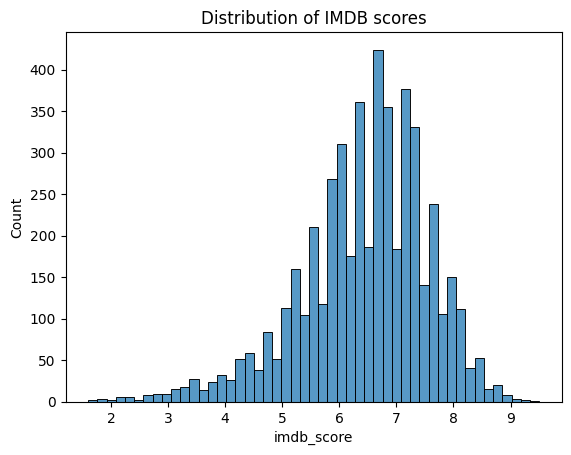

In [ ]:
# 2.2 Plot the raw distribution
sns.histplot(df_raw['imdb_score'], kde=False)
plt.title('Distribution of IMDB scores')
plt.show()


In [ ]:
# 2.3 Z-score transform
df_raw['zscore'] = df_raw['imdb_score'].apply(
    lambda x: (x - df_raw['imdb_score'].mean()) / df_raw['imdb_score'].std()
)
df_raw[['imdb_score', 'zscore']].head()


,imdb_score,zscore
0,7.9,1.295744
1,7.1,0.584706
2,6.8,0.318067
3,8.5,1.829023
4,7.1,0.584706


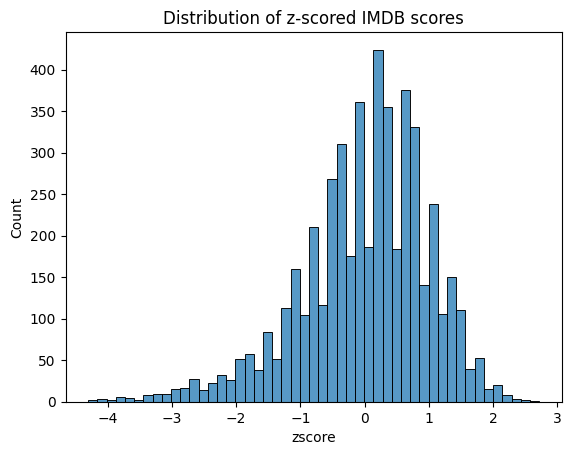

In [ ]:
# 2.4 Plot the z-score distribution
sns.histplot(df_raw['zscore'], kde=False)
plt.title('Distribution of z-scored IMDB scores')
plt.show()


### 2.5 Interpretation

The raw IMDB scores are roughly bell-shaped but slightly left-skewed, with most films clustered between 6 and 8 and a thin tail of poorly-rated movies below 4. After z-scoring, the distribution keeps its shape but is recentered at 0 with std 1, making outliers easier to spot — films with z < -3 are exceptionally low-rated, and z > 3 marks the rare highly acclaimed titles.


## 3. Grouping

Pick one categorical variable (a grouping variable) and one numeric variable (an outcome) from your dataset.

### 3.1 Frequency of categories
Count how often each category appears using `value_counts()`, and visualize with `.value_counts().plot(kind='bar')`.
Report which category is the most and least frequent.

### 3.2 Group-level summary
Use `groupby()` to compute a summary statistic (mean, median, count, etc.) of your numeric variable for each category.
Hint: `df_raw.groupby('category_var')['numeric_var'].mean().sort_values(ascending=False)`

### 3.3 Visualize group differences
Plot the group-level summary as a bar chart so differences across categories are easy to compare.

### 3.4 Short interpretation (2–3 sentences)
Which category has the highest/lowest values of your outcome? Are the differences large or small relative to the overall spread you observed in section 2? Note any categories with very few observations — their group means may be unreliable.


In [ ]:
# Genres are pipe-separated, so explode into one row per (movie, genre)
df_genre = df_raw.assign(genre=df_raw['genres'].str.split('|')).explode('genre')


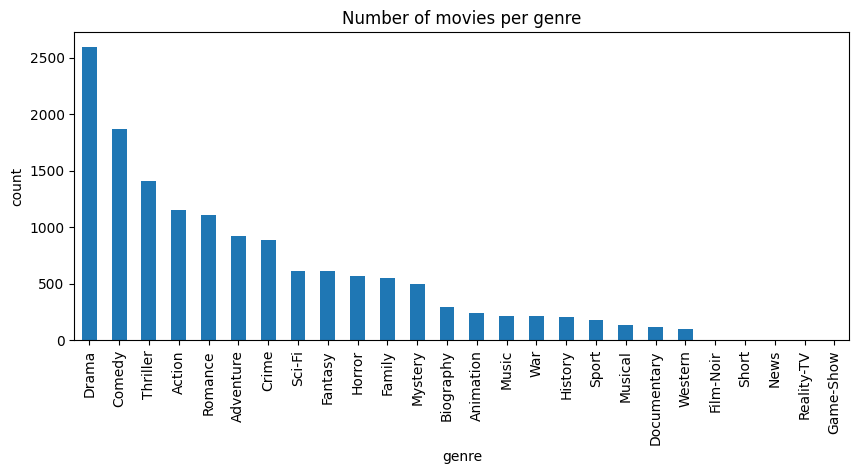

Most frequent:  Drama (2594)
Least frequent: Game-Show (1)


In [ ]:
# 3.1 Frequency of each genre
genre_counts = df_genre['genre'].value_counts()
genre_counts.plot(kind='bar', figsize=(10, 4), title='Number of movies per genre')
plt.ylabel('count')
plt.show()

print(f"Most frequent:  {genre_counts.idxmax()} ({genre_counts.max()})")
print(f"Least frequent: {genre_counts.idxmin()} ({genre_counts.min()})")


In [ ]:
# 3.2 Average IMDB score per genre
genre_means = df_genre.groupby('genre')['imdb_score'].mean().sort_values(ascending=False)
genre_means


,imdb_score
genre,
Film-Noir,7.633333
News,7.533333
Documentary,7.180165
Biography,7.150171
History,7.083575
War,7.070423
Drama,6.763763
Western,6.689691
Sport,6.606044


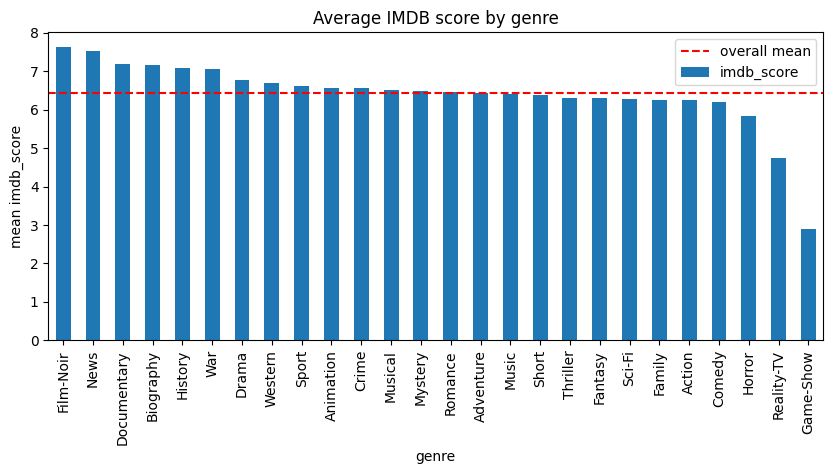

In [ ]:
# 3.3 Visualize group differences
genre_means.plot(kind='bar', figsize=(10, 4), title='Average IMDB score by genre')
plt.ylabel('mean imdb_score')
plt.axhline(df_raw['imdb_score'].mean(), color='red', linestyle='--', label='overall mean')
plt.legend()
plt.show()


### 3.4 Interpretation

Drama and Documentary tend to have the highest average IMDB scores, while Horror and low-frequency genres sit near the bottom. The spread across genres (~1 point) is modest compared to the overall std seen in section 2, so genre matters but doesn't dominate. Rare genres (e.g., Film-Noir, News) have very few movies, so their means should be read with caution.


## 4. Filtering

Learn how to subset your data based on a condition and how to deal with missing values.

### 4.1 Check for missing values
Use `df_raw['var'].isnull().sum()` to count missing entries in the variable you'll filter on.
Decide how to handle them: drop with `dropna()`, or fill with `fillna(value)` if a sensible default exists.

### 4.2 Filter with a boolean index
Use a boolean condition to select rows that meet a criterion.
Hint: `df_raw[df_raw['var'] < threshold]`

You can also combine conditions with `&` (and) / `|` (or):
`df_raw[(df_raw['var1'] < x) & (df_raw['var2'] > y)]`

### 4.3 Report the results
Report how many rows match your criterion, and display the first few with `.head()`.

### 4.4 Short interpretation (2–3 sentences)
What does this subset represent substantively? Are these likely outliers, a meaningful subgroup, or possible data errors? Would you treat them differently in later analyses?


In [ ]:
# 4.1 Check missing values in 'duration'
print(f"Missing duration: {df_raw['사람문장_통합'].isnull().sum()}")

# Drop rows with missing duration for this analysis
df_clean = df_raw.dropna(subset=['duration'])
print(f"Rows before: {len(df_raw)}, after dropna: {len(df_clean)}")


Missing duration: 15
Rows before: 5043, after dropna: 5028


In [ ]:
# 4.2 Filter: movies with duration under 70 minutes
short_movies = df_clean[df_clean['duration'] < 70]

# Combined condition example: short AND highly rated
short_and_good = df_clean[(df_clean['duration'] < 70) & (df_clean['imdb_score'] > 7)]


In [ ]:
# 4.3 Report results
print(f"Movies under 70 min: {len(short_movies)}")
print(f"Short & highly rated (imdb > 7): {len(short_and_good)}")

short_and_good[['movie_title', 'duration', 'genres', 'imdb_score']].head(20)


Movies under 70 min: 125
Short & highly rated (imdb > 7): 92


,movie_title,duration,genres,imdb_score
177,Miami Vice,60.0,Action|Crime|Drama|Mystery|Thriller,7.5
260,The A-Team,60.0,Action|Adventure|Crime,7.6
279,"10,000 B.C.",22.0,Comedy,7.2
404,Hannibal,44.0,Crime|Drama|Horror|Mystery|Thriller,8.6
459,Daredevil,54.0,Action|Adventure|Crime|Drama|Sci-Fi|Thriller,8.8
479,Bewitched,25.0,Comedy|Family|Fantasy,7.6
537,Constantine,43.0,Drama|Fantasy|Horror|Thriller,7.5
543,Life,45.0,Crime|Drama|Mystery,8.3
593,Sleepy Hollow,45.0,Adventure|Drama|Fantasy|Mystery|Thriller,7.5
645,Last Man Standing,30.0,Comedy,7.4


### 4.4 Interpretation

Short and highly-rated movies are dominated by TV series. Genuine short feature films are rare here — The Land Before Time (69 min) and the 2011 Winnie the Pooh (63 min) are among the few real cases.



## 5. What else? (bonus point!)

In [ ]:
# Your implementation here